# lead generation workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import operator
from typing import TypedDict, Optional, Annotated, List, Literal
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage
from langchain_community.document_loaders import WebBaseLoader
from tavily import TavilyClient
import os
from langchain_ollama import ChatOllama
import operator
from datetime import datetime


C:\Users\Roshan\AppData\Local\Temp\ipykernel_44800\4021833780.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
tavily_client = TavilyClient(api_key="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")

In [3]:
class leadgenstate(TypedDict, total=False):

    message:Annotated[List[BaseMessage], add_messages]
    intent:str
    worker_result:Optional[str]
    latest_message:str
    target_industry: Optional[str]
    target_location: Optional[str]
    target_count:int
    query:list[str]

    search_result:Annotated[List[dict], operator.add]
    usefull_lead:Annotated[List[dict], operator.add]
    clean_leads:Annotated[List[dict], operator.add]

    total_website_search:int
    total_websites_scrap:int
    duplicates_removed:int
    final_report: str
    lead_saved_location:Optional[str]

In [4]:
class lead_planner(BaseModel):
    target_industry: str = Field(description="The industry or type of business the user wants as leads.")
    target_location: str = Field(description="The geographical location where leads should be found.")
    target_count: int = Field(description="The number of leads the user wants.")
    search_queries: list[str]= Field(description="A list of effective web search queries for finding the requested leads.")

In [5]:
class extract_output(BaseModel):
    company_name: Optional[str] = Field(description="extract the company name which are mention on this page")
    email: Optional[str] = Field(description="extract the first email of this page")
    contact: Optional[str] = Field(description="extract the first contact number of this page")
    location: Optional[str] = Field(description="extract the first location of this page")
    link: Optional[str] = Field(description="extract the url")

In [6]:
class superviser(BaseModel):
    intent: Literal['respond', 'planner'] = Field(description="Return 'planner' when the user wants to perform a lead generation task. Return 'respond' for normal conversation or questions about the agent's capabilities.")
    reply: str = Field(description="A helpful response to the user's message.")

In [ ]:
model=-ChatOllama(model = 'qwen3.8:27b', temperature=0)

In [8]:

plannerlead_st_model=model.with_structured_output(lead_planner)
extract_info_lead_model=model.with_structured_output(extract_output)
supervisermodel=model.with_structured_output(superviser)


In [9]:
def superviser(state:leadgenstate):
    if state.get("worker_result"):
        final_response = f'{state["worker_result"]}\n here is the saved location of lead {state["lead_saved_location"]}'
        return {"message": [AIMessage(content=final_response)], "intent":"respond", "worker_result": None}
    
    user_messages= None
    for msg in reversed(state["message"]):
        if isinstance(msg, HumanMessage):
            user_messages=msg.content
            break
    if not user_messages:
        print("no user message found")

    messages=[SystemMessage(content="""
You are the supervisor of a lead generation agent.
Your job is to understand the user's message and decide whether
the user wants to START a lead generation task or is simply asking
about the agent's capabilities.
You must return the correct Pydantic structured output.
The agent is specifically designed for LEAD GENERATION.
It can:
- find companies or businesses
- search for businesses in a specific industry and location
- find contact information
- find phone numbers
- find email addresses
- find addresses
- find official websites
- collect and organize business leads
IMPORTANT:
There are TWO different types of user messages.
TYPE 1 — CAPABILITY / INFORMATION QUESTION
If the user is only asking what you can do, whether you can do
something, or asking about your capabilities, DO NOT start lead
generation.
Examples:
User:
"What can you do?"
User:
"What can you help me with?"
User:
"Are you a lead generation agent?"
User:
"Can you find digital marketing agencies?"
User:
"Can you find 5 digital marketing agencies in Mumbai?"
For these messages:
- intent = "respond"
- Give a short helpful answer explaining that you can perform
  lead generation.
- DO NOT send the request to the planner.
- DO NOT perform a search.
Example response:
"Yes, I can find digital marketing agencies in Mumbai and collect
their contact details and official websites for you. If you want
me to do it, tell me how many leads you need."
TYPE 2 — ACTUAL LEAD GENERATION REQUEST
If the user clearly instructs you to find/search/generate/collect
leads, then send the request to the planner.
Examples:
"Find 5 digital marketing agencies in Mumbai with their contact
details and official websites."
"Search for 10 software companies in Delhi."
"Give me 5 AI companies in Bangalore with phone numbers."
For these messages:
- intent = "planner"
- Send the request to the planner.
- Do not answer with a capability explanation.
IMPORTANT DISTINCTION:
"Can you find 5 digital marketing agencies in Mumbai?"
means the user is asking whether you are capable of doing it.
Therefore respond directly and DO NOT search.
"Find 5 digital marketing agencies in Mumbai."
means the user is instructing you to perform the task.
Therefore route to the planner.
For normal conversation that is unrelated to lead generation,
use:
- intent = "respond"
For actual lead generation tasks, use:
- intent = "planner"
Do not invent information.
Return only the structured information required by the Pydantic schema.
"""), HumanMessage(content=user_messages)]
    response = supervisermodel.invoke(messages)
    return {"intent": response.intent, "message":[AIMessage (content=response.reply)]}

In [10]:
def planner_agent(state: leadgenstate):
    print("--planning the user query wait some time after complitaion i will send to researcher agent")
    user_message= None
    for msg in reversed(state["message"]):
        if isinstance(msg, HumanMessage):
            user_message=msg.content
            break
    if not user_message:
        print("no user message found")
    messages = [
        SystemMessage(
            content="""
You are a lead generation planning agent.

Your job is to analyse the user's request and extract:

1. target industry
2. target location
3. target number of leads
4. useful web search queries

The main goal is to find REAL businesses or companies and collect
their contact information from their official websites.

Search query rules:

- Create 5 to 7 different search queries.
- Every query must contain the target industry and target location.
- Prefer queries that can discover official company websites.
- Include terms such as:
  "official website"
  "contact us"
  "contact"
  "phone"
  "email"
  "address"
  when useful.
- Create variations of the search intent instead of repeating
  nearly identical queries.
- Do not focus mainly on ranking, reviews, "best companies",
  or comparison websites.
- Avoid queries specifically targeting directories, review websites,
  or business listing websites unless they are useful for discovering
  company names.
- The final lead information should ideally come from the company's
  own website.
- Do not invent missing information.
- Return only the structured information requested.
"""
        ),
        HumanMessage(
            content=f"""
Analyse this lead generation request:
{user_message}
"""
        )
    ]
    result=plannerlead_st_model.invoke(messages)
    return {'target_industry': result.target_industry, 'target_location': result.target_location, 'target_count': result.target_count, 'query':result.search_queries}

In [11]:
def researcher(state:leadgenstate):
    print("searching start")
    search_result=[]
    for query in state["query"]:
        try:
           response=tavily_client.search(query=query, search_depth="advanced", max_results=10)
           results= response.get("results", [])
           for result in results:
               search_result.append({
                   "query": query,
                   "url": result.get("url"),
                   "content": result.get("content")
                   })
        except Exception as e:
            print("something went wrong", e)

    return {"search_result": search_result, "total_website_search": len(search_result)}


In [12]:
def extract_info(state:leadgenstate):
    print("---removing duplicates link and excraping website----")
    leads=[]
    seen=set()
    total_websites_scrap=0
    for lead in state["search_result"]:
        url = lead.get("url")
        if url and  url not in seen:
            seen.add(url)

            try:
                loader=WebBaseLoader(url)
                total_websites_scrap += 1
                results = loader.load()
                raw_text = "\n".join([r.page_content for r in results])
                raw_text = " ".join(raw_text.split())
                content_to_process = raw_text[:12000]

                messages = [SystemMessage(content="""
You are an expert website contact information extraction agent.
Your task is to extract ONLY the PRIMARY contact information belonging to
the main company/business/website owner represented by this webpage.
IMPORTANT RULES:
1. Extract exactly ONE primary company/business name.
2. Extract exactly ONE primary email address.
3. Extract exactly ONE primary phone/contact number.
4. Extract exactly ONE primary physical location/address.
5. DO NOT extract contact information belonging to:
   - other companies
   - competitors
   - clients
   - third-party businesses
   - companies mentioned inside blogs, lists, directories, or articles
6. If a field is not available for the PRIMARY company, return null.
PHONE NUMBER NORMALIZATION RULES:
- Return the phone number in a CONSISTENT format.
- If the phone number is an Indian number, ALWAYS include the country
  code +91.
- If the page contains both:
      8587804924
  and
      +91-8587804924
  treat them as the SAME phone number.
- NEVER return the same phone number in two different formats.
- Remove spaces, hyphens, brackets, and other formatting characters.
- For Indian numbers, the final format MUST be:
      +918587804924
- Do NOT change the actual digits of the phone number.
- Do NOT invent a country code when the country cannot be determined.
- If multiple phone numbers belong to the PRIMARY company, select only
  the main/primary contact number.
EMAIL NORMALIZATION RULES:
- Return the email exactly once.
- Convert the email to lowercase.
- Remove unnecessary spaces around the email.
- Do not invent or modify the email address.
COMPANY NAME RULES:
- Return the official/main company name as shown on the website.
- Do not return names of companies merely mentioned in articles or lists.
OUTPUT:
Return only the requested structured fields:
company_name
email
contact
location
link

If a field cannot be confidently extracted, return null.
"""),
                    HumanMessage(content=f"Website URL: {url}\n\nHere is the website text:\n\n{content_to_process}")
                    ]

                result=extract_info_lead_model.invoke(messages)
                lead_info=result.model_dump()
                lead_info["link"]=url
                if lead_info.get("email") or lead_info.get("contact"):
                    leads.append(lead_info)
            except Exception as e:
                print("something went wrong", e)
    return {"usefull_lead": leads, "total_websites_scrap": total_websites_scrap}
                    

In [13]:
def remove_duplicate(state:leadgenstate):
    print("---removing duplicate---")
    clean_lead=[]
    seen = set()
    for i in state["usefull_lead"]:
        key = (i.get("email"), i.get("contact"))
        if key not in seen and (i.get("email") or i.get("contact")):
            seen.add(key)
            clean_lead.append(i)
    duplicates_removed = len(state["usefull_lead"]) - len(clean_lead)
    return{"clean_leads": clean_lead[:state["target_count"]], "duplicates_removed":duplicates_removed}


In [14]:
import pandas as pd
def report_generator(state:leadgenstate):
    print("---report generating---")
    data = state["clean_leads"]
    df = pd.DataFrame(data)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath=rf"C:\Users\Roshan\Downloads\your_lead_{timestamp}.csv"
    df.to_csv(filepath, index=False)
    messages = [SystemMessage(content=""" you are a lead generation repoting agent. create a concise final report based only on the
    provided statitics do not invent any numbers
    include:
    -total website searched
    -total websites scraped
    -duplicates removed
    also mention wheather the requested target count was achived """),
            HumanMessage(content=f"""
             lead generation statistics:
             Target leads: {state["target_count"]}
             
            total websites searched:
            {state["total_website_search"]}
 
            total website scraped:
            {state["total_websites_scrap"]}

            duplicates removed:
            {state["duplicates_removed"]}""")
                                               ]
    response= model.invoke(messages).content
    return {"final_report": response, "worker_result": response, "lead_saved_location":filepath}



In [15]:
def route(state:leadgenstate):
    if state["intent"]== "planner":
        return "planner"
    else:
        return END

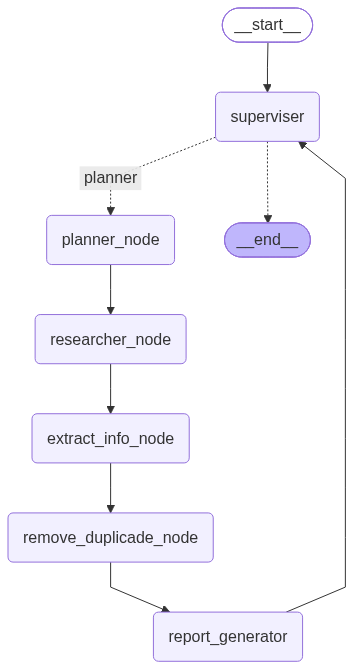

In [16]:
graph=StateGraph(leadgenstate)

graph.add_node("superviser", superviser)
graph.add_node("planner_node", planner_agent)
graph.add_node("researcher_node", researcher)
graph.add_node("extract_info_node", extract_info)
graph.add_node("remove_duplicade_node", remove_duplicate)
graph.add_node("report_generator", report_generator)

graph.add_edge(START, "superviser")
graph.add_conditional_edges("superviser", route, {"planner": "planner_node", END:END})
graph.add_edge("planner_node", "researcher_node")
graph.add_edge("researcher_node", "extract_info_node")
graph.add_edge("extract_info_node", "remove_duplicade_node")
graph.add_edge("remove_duplicade_node", "report_generator")
graph.add_edge("report_generator", "superviser")

workflow=graph.compile()
workflow

In [ ]:
while True:
    query= input("enter your query")
    if query.lower() in ["bye", "stop", "quit"]:
        break
    result=workflow.invoke({"message": [HumanMessage(content=query)]})
    result1=result['message'][-1].content
    print("bot reply: ", result1)



bot reply:  Hi there! 👋 I'm a lead generation agent. I can help you find companies or businesses in a specific industry and location, and collect their contact details like phone numbers, email addresses, physical addresses, and official websites. Just let me know what you're looking for — for example, "Find 5 digital marketing agencies in Mumbai with their contact details." How can I help you today?
bot reply:  I'm doing well, thank you! I'm here and ready to help. If you'd like me to find businesses, collect contact details, or generate leads for a specific industry and location, just let me know what you need.
--planning the user query wait some time after complitaion i will send to researcher agent
searching start
---removing duplicates link and excraping website----
---removing duplicate---
---report generating---
bot reply:  # Lead Generation – Final Report

**Target Leads:** 10

| Metric | Count |
|---|---|
| Total Websites Searched | 70 |
| Total Websites Scraped | 53 |
| Dupli